# 📊 Hindi Legal Judgments Dataset — Data Visualization
### Exploratory Data Analysis & Visual Insights

This notebook performs comprehensive data visualization on the Hindi court judgments dataset to extract meaningful patterns across case types, subjects, legal aspects, and judgment text characteristics.

In [6]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.6/525.6 kB 1.1 MB/s  0:00:006m0:00:01
    torch (>=1.7.*)
           ~~~~~~^


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from collections import Counter
import textwrap
import warnings
warnings.filterwarnings('ignore')

# Use a clean style
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['font.size'] = 11

# Custom color palette
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107', '#9C27B0', '#00BCD4', '#E91E63', '#795548']


/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import subprocess
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)


Sat Jul  4 13:16:16 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090         On | 00000000:3B:00.0 Off |                  N/A |
|  0%   52C    P8               25W / 350W|      8MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
!kill 33774 43478 43478

In [3]:
# Load the dataset
df = pd.read_csv('final_merged_hindi_cleaned.csv', encoding='utf-8-sig')

# Basic info
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nCase Types: {df['case_type'].nunique()} unique")
print(f"Subjects:   {df['subject'].nunique()} unique")
print(f"Objects:    {df['object'].nunique()} unique")


Dataset Shape: 742 rows × 10 columns

Columns: ['case_id', 'language', 'case_type', 'judgment_text', 'subject', 'object', 'objective_aspect', 'subjective_aspect', 'legal_provision', 'reasoning']

Missing Values:
case_id                0
language               0
case_type              0
judgment_text          0
subject               14
object                14
objective_aspect      14
subjective_aspect     14
legal_provision      742
reasoning            742
dtype: int64

Case Types: 4 unique
Subjects:   653 unique
Objects:    387 unique


In [4]:
df.head(10)

,case_id,language,case_type,judgment_text,subject,object,objective_aspect,subjective_aspect,legal_provision,reasoning
0,CHG_ADM_000001,Hindi,Administrative,\n\n2023-CGHC:17318-08\n\nएएफआर\nछत्तीसगढ़ उच...,Director General of Police,Police Officer / Employee,Disciplinary Proceeding,Delay in Decision,NaN,NaN
1,CHG_ADM_000002,Hindi,Administrative,"छत्तीसगढ़ का उच्च न्यायालय, बिलासपुर\nडब्ल्यू,...",Municipal Authority,Petitioner / Appellant,Dismissal / Termination Order,Violation of Natural Justice,NaN,NaN
2,CHG_ADM_000003,Hindi,Administrative,\n\nतटस्थ उद्धरण\n2023:सीजीएचसीः29932-डीबी\n\...,South Eastern Coalfields Limited (SECL),Institution / Society,Administrative Order,Delay in Decision,NaN,NaN
3,CHG_ADM_000004,Hindi,Administrative,"\n\nएएफआर\nछत्तीसगढ़ उच्च न्यायालय, बिलासपुर\...",School Education Department,Government Employee (Principal),Recruitment / Selection Decision,Violation of Natural Justice,NaN,NaN
4,CHG_ADM_000005,Hindi,Administrative,"""\n11. मर्िपति नागराजा (पूरवोक्त) के मामले में...",Coal India Limited,Candidate,Transfer Order,Arbitrary Exercise of Power,NaN,NaN
5,CHG_ADM_000006,Hindi,Administrative,\n\nडब्ल्यूपी 227 क्र. 1011/ 2018\n\n*. इंतेज...,Not Clearly Specified,Institution / Society,Administrative Order,Illegal Administrative Action,NaN,NaN
6,CHG_ADM_000007,Hindi,Administrative,"\n\nछत्तीसगढ़ उच्च न्यायालय, बिलासपुर\nडब्ल्य...",Not Clearly Specified,Institution / Society,Administrative Order,Illegal Administrative Action,NaN,NaN
7,CHG_ADM_000008,Hindi,Administrative,"\n\nएएफआर\nछत्तीसगढ़ उच्च न्यायालय, बिलासपुर\...",State of Chhattisgarh,Citizen,Administrative Order,Not Clearly Specified,NaN,NaN
8,CHG_ADM_000009,Hindi,Administrative,"\n\n'एएफआर\nछत्तीसगढ़ उच्च न्यायालय, बिलासपुर...",Bank Authority,Petitioner / Appellant,Administrative Order,Not Clearly Specified,NaN,NaN
9,CHG_ADM_000010,Hindi,Administrative,"\n\nछत्तीसगढ़ उच्च न्यायालय, बिलासपुर\nडब्ल्य...",Not Clearly Specified,Contractor / Private Entity,Recruitment / Selection Decision,Delay in Decision,NaN,NaN


In [5]:
# Data Cleaning & Feature Engineering
# Keep only valid case_type rows (remove the 2 noisy rows)
valid_types = ['Criminal', 'Administrative', 'Civil', 'Constitutional']
df_clean = df[df['case_type'].isin(valid_types)].copy()

# Add text length features
df_clean['text_length'] = df_clean['judgment_text'].apply(lambda x: len(str(x)))
df_clean['word_count'] = df_clean['judgment_text'].apply(lambda x: len(str(x).split()))

print(f"Clean dataset: {df_clean.shape[0]} rows")
print(f"\nWord count stats:\n{df_clean['word_count'].describe().round(0)}")


Clean dataset: 742 rows

Word count stats:
count     742.0
mean     1442.0
std      1565.0
min         1.0
25%       335.0
50%       648.0
75%      2176.0
max      6237.0
Name: word_count, dtype: float64


## 1. Case Type Distribution

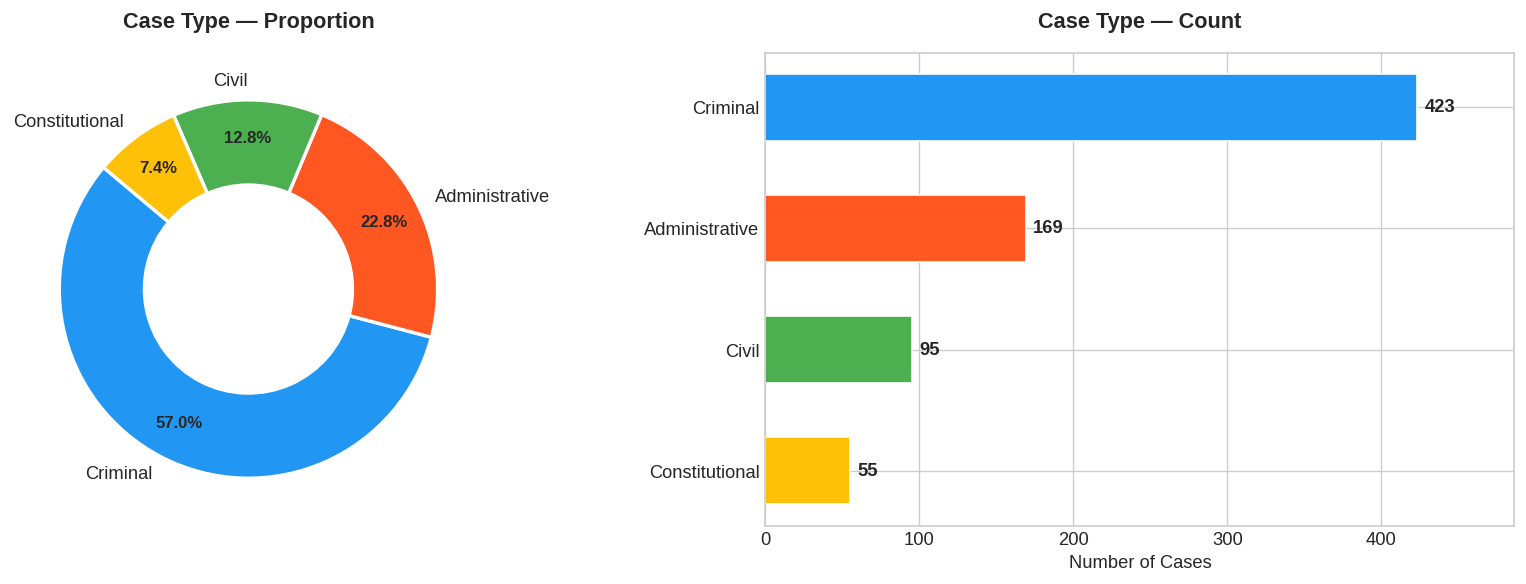

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

case_counts = df_clean['case_type'].value_counts()

# Pie Chart
wedges, texts, autotexts = ax1.pie(
    case_counts.values, labels=case_counts.index,
    autopct='%1.1f%%', colors=COLORS[:len(case_counts)],
    startangle=140, pctdistance=0.8,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax1.set_title('Case Type — Proportion', fontsize=13, fontweight='bold', pad=15)

# Horizontal Bar
bars = ax2.barh(case_counts.index[::-1], case_counts.values[::-1], color=COLORS[:len(case_counts)][::-1],
                edgecolor='white', height=0.55)
for bar, val in zip(bars, case_counts.values[::-1]):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', fontsize=11)
ax2.set_xlabel('Number of Cases', fontsize=11)
ax2.set_title('Case Type — Count', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlim(0, max(case_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('01_case_type_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()


## 2. Missing Data Heatmap

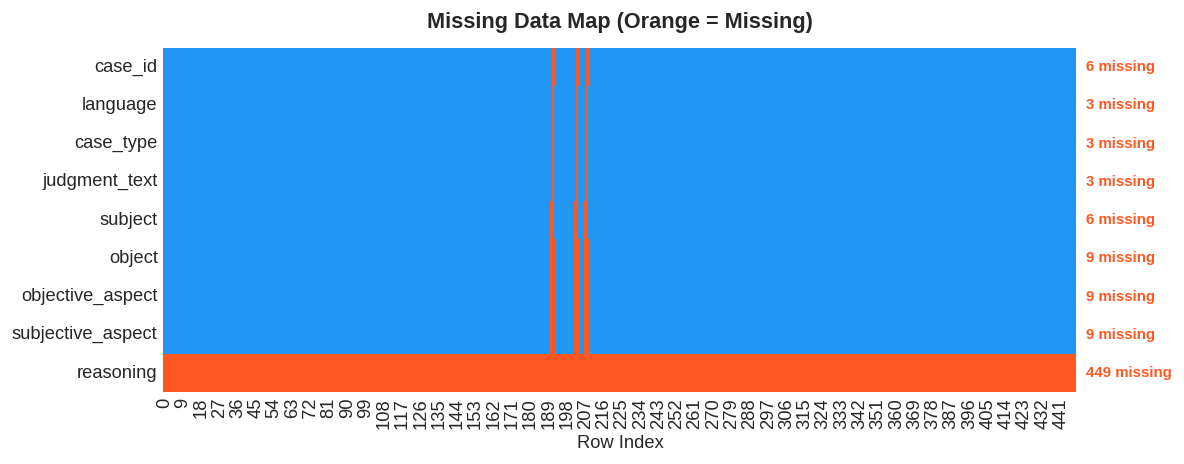

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

missing = df.isnull().T  # columns as rows
sns.heatmap(missing, cbar=False, cmap=['#2196F3', '#FF5722'],
            yticklabels=df.columns, ax=ax)
ax.set_xlabel('Row Index', fontsize=11)
ax.set_title('Missing Data Map (Orange = Missing)', fontsize=13, fontweight='bold', pad=12)

# Add counts on the right
for i, col in enumerate(df.columns):
    n_miss = df[col].isnull().sum()
    ax.text(len(df) + 5, i + 0.5, f'{n_miss} missing', va='center', fontsize=9,
            color='#FF5722' if n_miss > 0 else '#4CAF50', fontweight='bold')

plt.tight_layout()
plt.savefig('02_missing_data_heatmap.png', bbox_inches='tight', facecolor='white')
plt.show()


## 3. Top 15 Subjects (Petitioners)

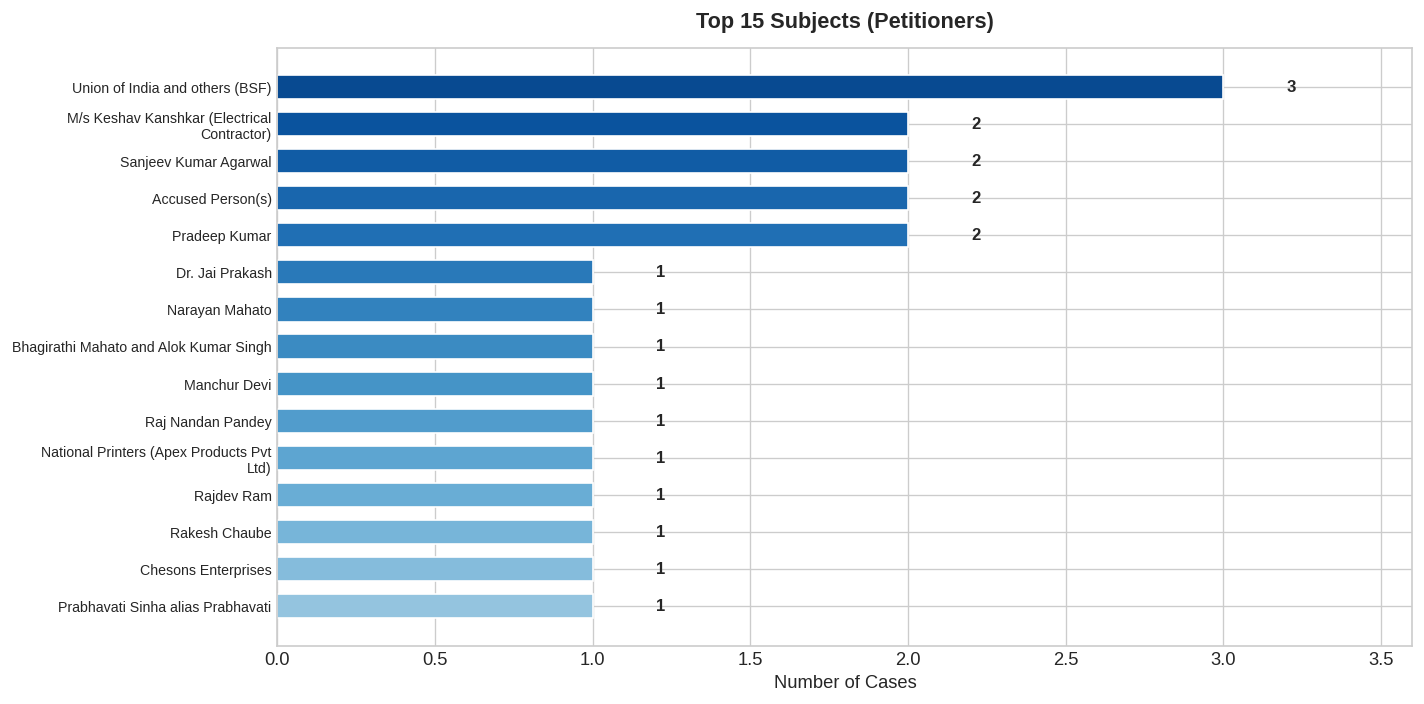

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

top_subjects = df_clean['subject'].value_counts().head(15)

# Wrap long labels
labels = [textwrap.fill(str(s), 40) for s in top_subjects.index[::-1]]

bars = ax.barh(range(len(top_subjects)), top_subjects.values[::-1],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top_subjects))),
               edgecolor='white', height=0.65)

for bar, val in zip(bars, top_subjects.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(top_subjects)))
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel('Number of Cases', fontsize=11)
ax.set_title('Top 15 Subjects (Petitioners)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(top_subjects.values) * 1.2)

plt.tight_layout()
plt.savefig('03_top_subjects.png', bbox_inches='tight', facecolor='white')
plt.show()


## 4. Top 15 Objects (Respondents)

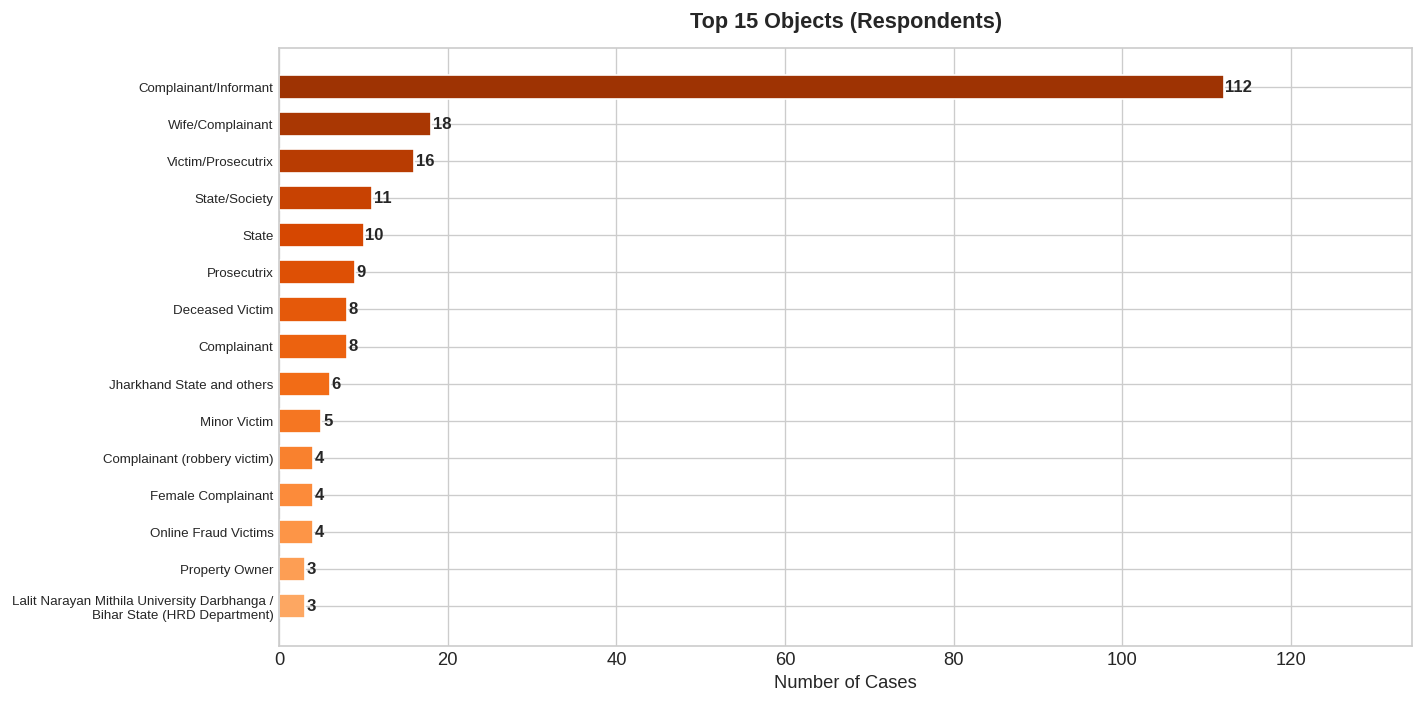

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

top_objects = df_clean['object'].value_counts().head(15)
labels = [textwrap.fill(str(s), 45) for s in top_objects.index[::-1]]

bars = ax.barh(range(len(top_objects)), top_objects.values[::-1],
               color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_objects))),
               edgecolor='white', height=0.65)

for bar, val in zip(bars, top_objects.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(top_objects)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Number of Cases', fontsize=11)
ax.set_title('Top 15 Objects (Respondents)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(top_objects.values) * 1.2)

plt.tight_layout()
plt.savefig('04_top_objects.png', bbox_inches='tight', facecolor='white')
plt.show()


## 5. Judgment Text Length by Case Type (Violin + Box Plot)

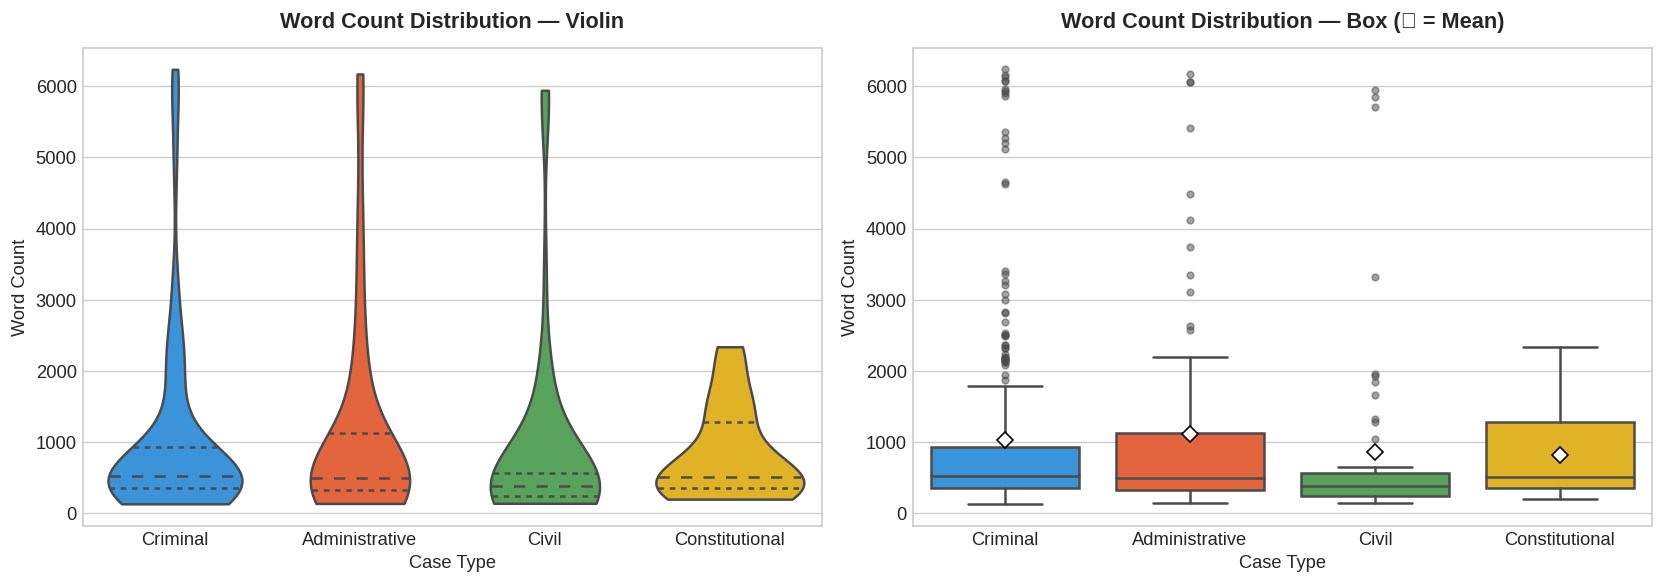

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

order = df_clean['case_type'].value_counts().index

# Violin Plot
sns.violinplot(data=df_clean, x='case_type', y='word_count', order=order,
               palette=COLORS[:4], inner='quartile', ax=ax1, cut=0)
ax1.set_xlabel('Case Type', fontsize=11)
ax1.set_ylabel('Word Count', fontsize=11)
ax1.set_title('Word Count Distribution — Violin', fontsize=13, fontweight='bold', pad=12)

# Box Plot
sns.boxplot(data=df_clean, x='case_type', y='word_count', order=order,
            palette=COLORS[:4], ax=ax2, flierprops=dict(marker='o', markersize=4, alpha=0.5))
# Add mean markers
means = df_clean.groupby('case_type')['word_count'].mean()
for i, ct in enumerate(order):
    ax2.plot(i, means[ct], 'D', color='white', markersize=7, markeredgecolor='black', zorder=5)
ax2.set_xlabel('Case Type', fontsize=11)
ax2.set_ylabel('Word Count', fontsize=11)
ax2.set_title('Word Count Distribution — Box (◆ = Mean)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('05_text_length_violin_box.png', bbox_inches='tight', facecolor='white')
plt.show()


## 6. Word Count Histogram (Stacked by Case Type)

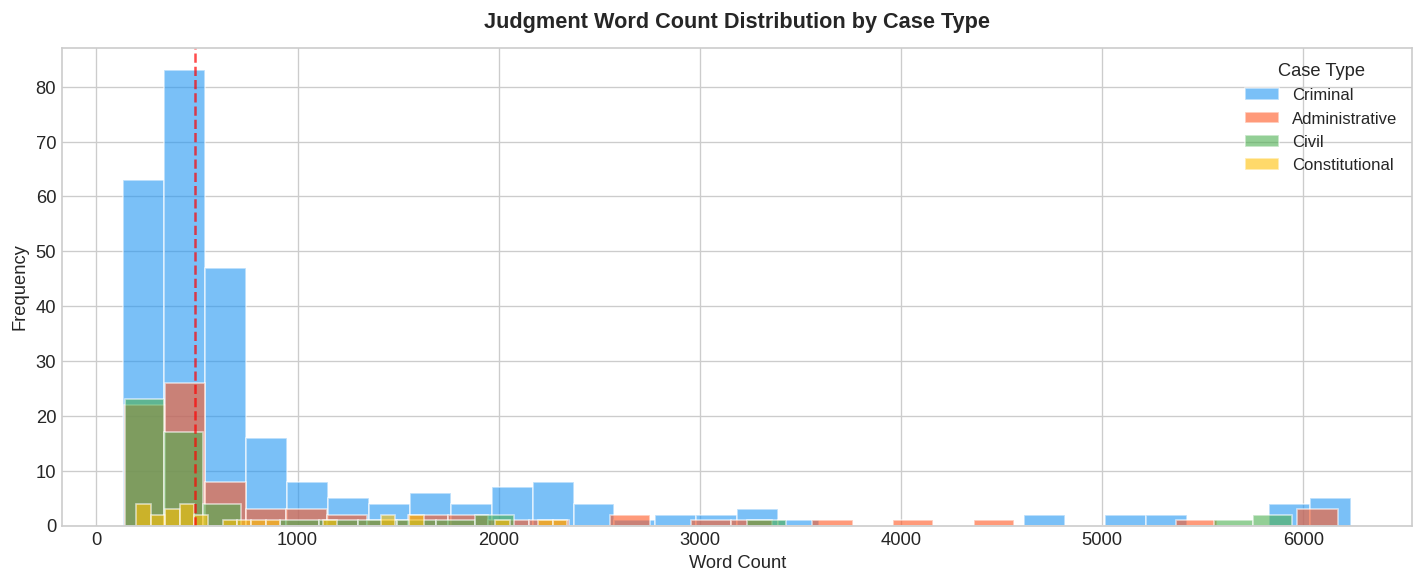

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, ct in enumerate(order):
    subset = df_clean[df_clean['case_type'] == ct]['word_count']
    ax.hist(subset, bins=30, alpha=0.6, label=ct, color=COLORS[i], edgecolor='white')

ax.set_xlabel('Word Count', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Judgment Word Count Distribution by Case Type', fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Case Type', fontsize=10)
ax.axvline(df_clean['word_count'].median(), color='red', linestyle='--', alpha=0.7, label='Median')

plt.tight_layout()
plt.savefig('06_word_count_histogram.png', bbox_inches='tight', facecolor='white')
plt.show()


## 7. Top Objective Aspects (Legal Issues Raised)

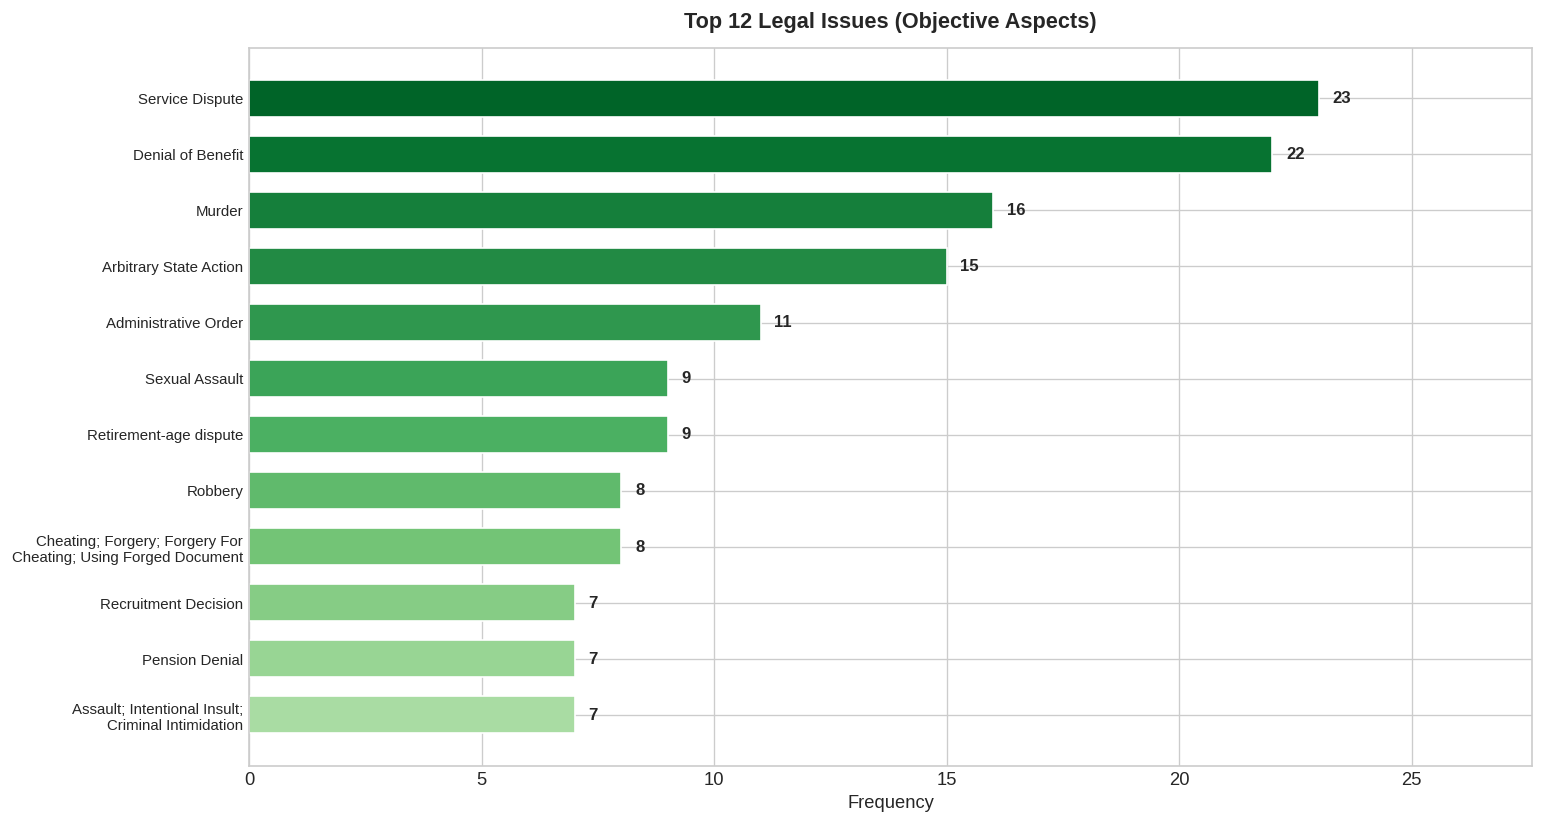

In [15]:
fig, ax = plt.subplots(figsize=(13, 7))

# Extract the main category from objective_aspect (before the parenthesis)
df_clean['obj_aspect_main'] = df_clean['objective_aspect'].dropna().apply(
    lambda x: x.split('(')[0].strip() if '(' in str(x) else str(x).strip()
)

top_aspects = df_clean['obj_aspect_main'].value_counts().head(12)
labels = [textwrap.fill(str(s), 35) for s in top_aspects.index[::-1]]

bars = ax.barh(range(len(top_aspects)), top_aspects.values[::-1],
               color=plt.cm.Greens(np.linspace(0.35, 0.9, len(top_aspects))),
               edgecolor='white', height=0.65)

for bar, val in zip(bars, top_aspects.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(top_aspects)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top 12 Legal Issues (Objective Aspects)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(top_aspects.values) * 1.2)

plt.tight_layout()
plt.savefig('07_top_objective_aspects.png', bbox_inches='tight', facecolor='white')
plt.show()


## 8. Case Type × Court Remedy — Cross-tabulation Heatmap

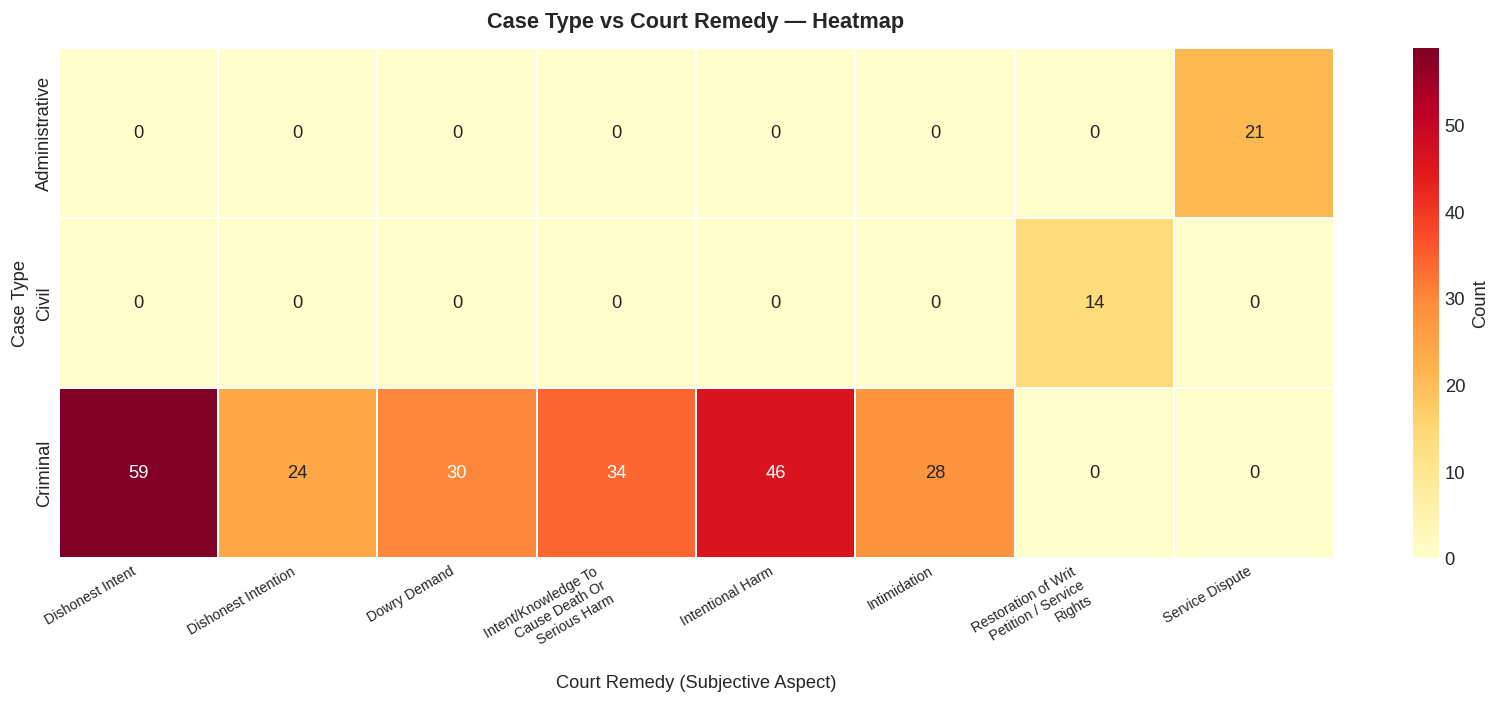

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

# Extract main subjective aspect
df_clean['subj_aspect_main'] = df_clean['subjective_aspect'].dropna().apply(
    lambda x: x.split('(')[0].strip() if '(' in str(x) else str(x).strip()
)

top_remedies = df_clean['subj_aspect_main'].value_counts().head(8).index
ct_remedy = pd.crosstab(
    df_clean[df_clean['subj_aspect_main'].isin(top_remedies)]['case_type'],
    df_clean[df_clean['subj_aspect_main'].isin(top_remedies)]['subj_aspect_main']
)

# Wrap column labels
ct_remedy.columns = [textwrap.fill(c, 20) for c in ct_remedy.columns]

sns.heatmap(ct_remedy, annot=True, fmt='d', cmap='YlOrRd', linewidths=1,
            linecolor='white', ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Court Remedy (Subjective Aspect)', fontsize=11)
ax.set_ylabel('Case Type', fontsize=11)
ax.set_title('Case Type vs Court Remedy — Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=8.5)

plt.tight_layout()
plt.savefig('08_casetype_remedy_heatmap.png', bbox_inches='tight', facecolor='white')
plt.show()


## 9. Legal Issues by Case Type (Grouped Stacked Bar)

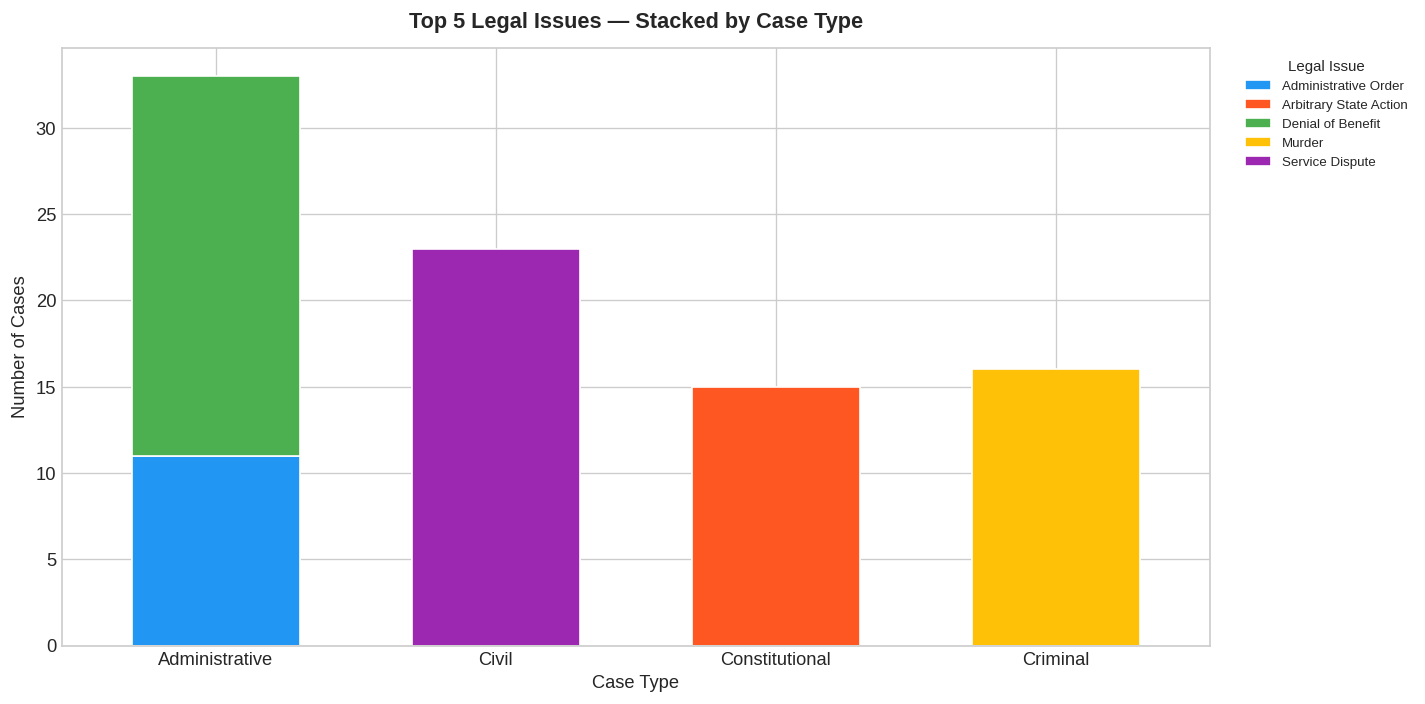

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

top5_obj = df_clean['obj_aspect_main'].value_counts().head(5).index
ct_obj = pd.crosstab(
    df_clean[df_clean['obj_aspect_main'].isin(top5_obj)]['case_type'],
    df_clean[df_clean['obj_aspect_main'].isin(top5_obj)]['obj_aspect_main']
)

ct_obj.columns = [textwrap.fill(c, 25) for c in ct_obj.columns]
ct_obj.plot(kind='bar', stacked=True, ax=ax, color=COLORS[:5], edgecolor='white', width=0.6)

ax.set_xlabel('Case Type', fontsize=11)
ax.set_ylabel('Number of Cases', fontsize=11)
ax.set_title('Top 5 Legal Issues — Stacked by Case Type', fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Legal Issue', fontsize=8, title_fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('09_legal_issues_stacked.png', bbox_inches='tight', facecolor='white')
plt.show()


## 10. Word Cloud — Hindi Judgment Text

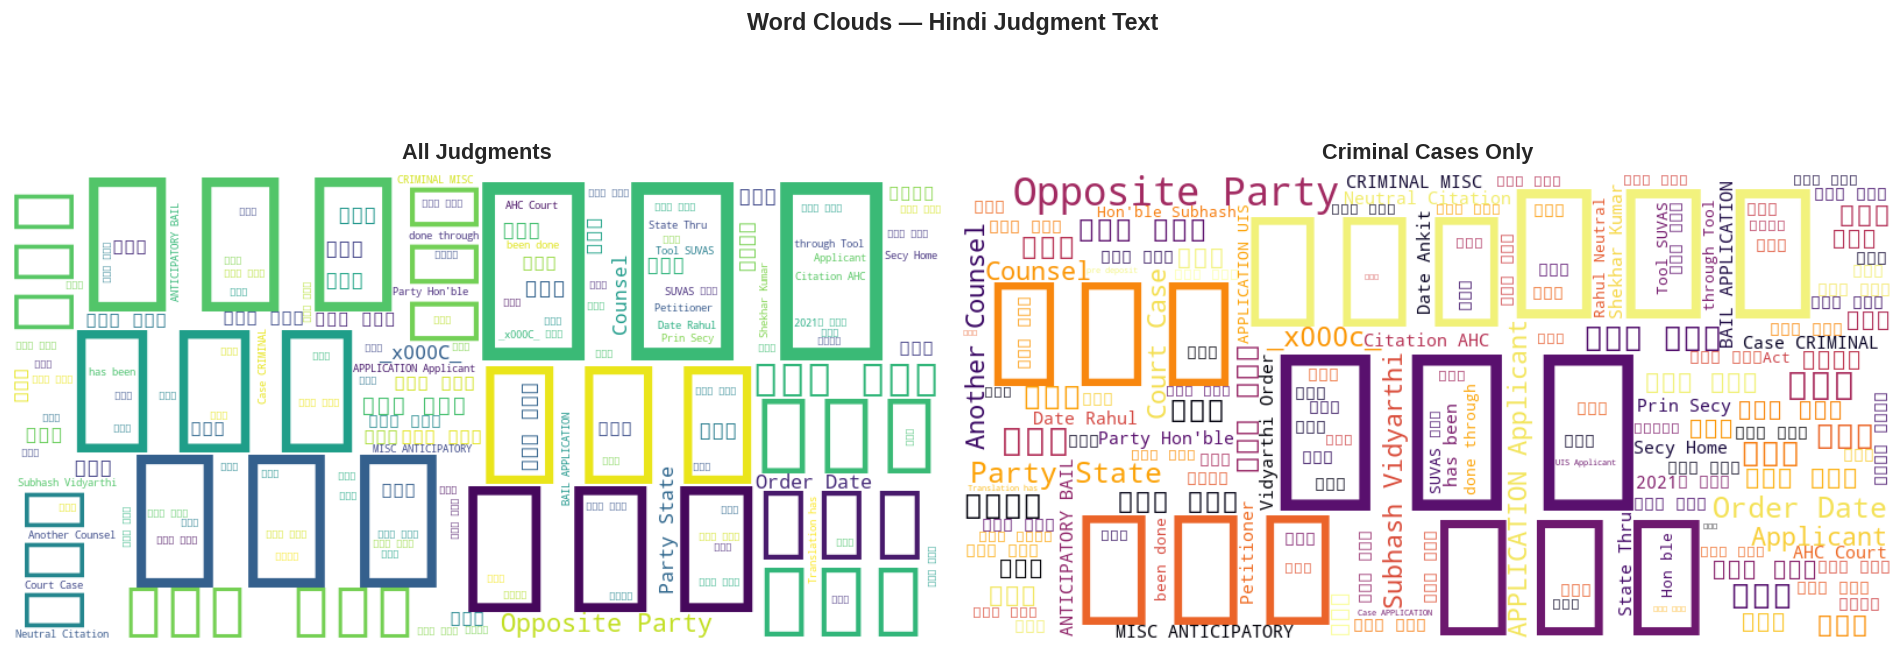

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stopwords (common Hindi + legal boilerplate)
hindi_stops = set(['के', 'का', 'की', 'में', 'है', 'और', 'को', 'से', 'पर', 'ने', 'यह',
                   'एक', 'हो', 'कि', 'नहीं', 'था', 'हैं', 'इस', 'जो', 'कर', 'या',
                   'थे', 'गया', 'गई', 'तथा', 'भी', 'द्वारा', 'अपने', 'बाद', 'उनके',
                   'वह', 'किया', 'जा', 'रहा', 'दिया', 'लिए', 'साथ', 'तक', 'अन्य',
                   'होने', 'करने', 'होता', 'उक्त', 'प्रति', 'कोई', 'दो', 'अभी', 'जब',
                   'रहे', 'हुए', 'जाता', 'रूप', 'सकता', 'इसके', 'बनाम', 'पटना', 'the',
                   'of', 'and', 'in', 'to', 'is', 'for', 'on', 'that', 'with', 'was'])

all_text = ' '.join(df_clean['judgment_text'].dropna().astype(str))

# Full word cloud
wc = WordCloud(width=800, height=400, background_color='white',
               max_words=150, colormap='viridis',
               stopwords=hindi_stops, min_word_length=3).generate(all_text)
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('All Judgments', fontsize=13, fontweight='bold', pad=10)

# Criminal only
criminal_text = ' '.join(df_clean[df_clean['case_type']=='Criminal']['judgment_text'].dropna().astype(str))
wc2 = WordCloud(width=800, height=400, background_color='white',
                max_words=150, colormap='inferno',
                stopwords=hindi_stops, min_word_length=3).generate(criminal_text)
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Criminal Cases Only', fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Word Clouds — Hindi Judgment Text', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('10_wordclouds.png', bbox_inches='tight', facecolor='white')
plt.show()


## 11. Summary Dashboard — 2×2 Grid

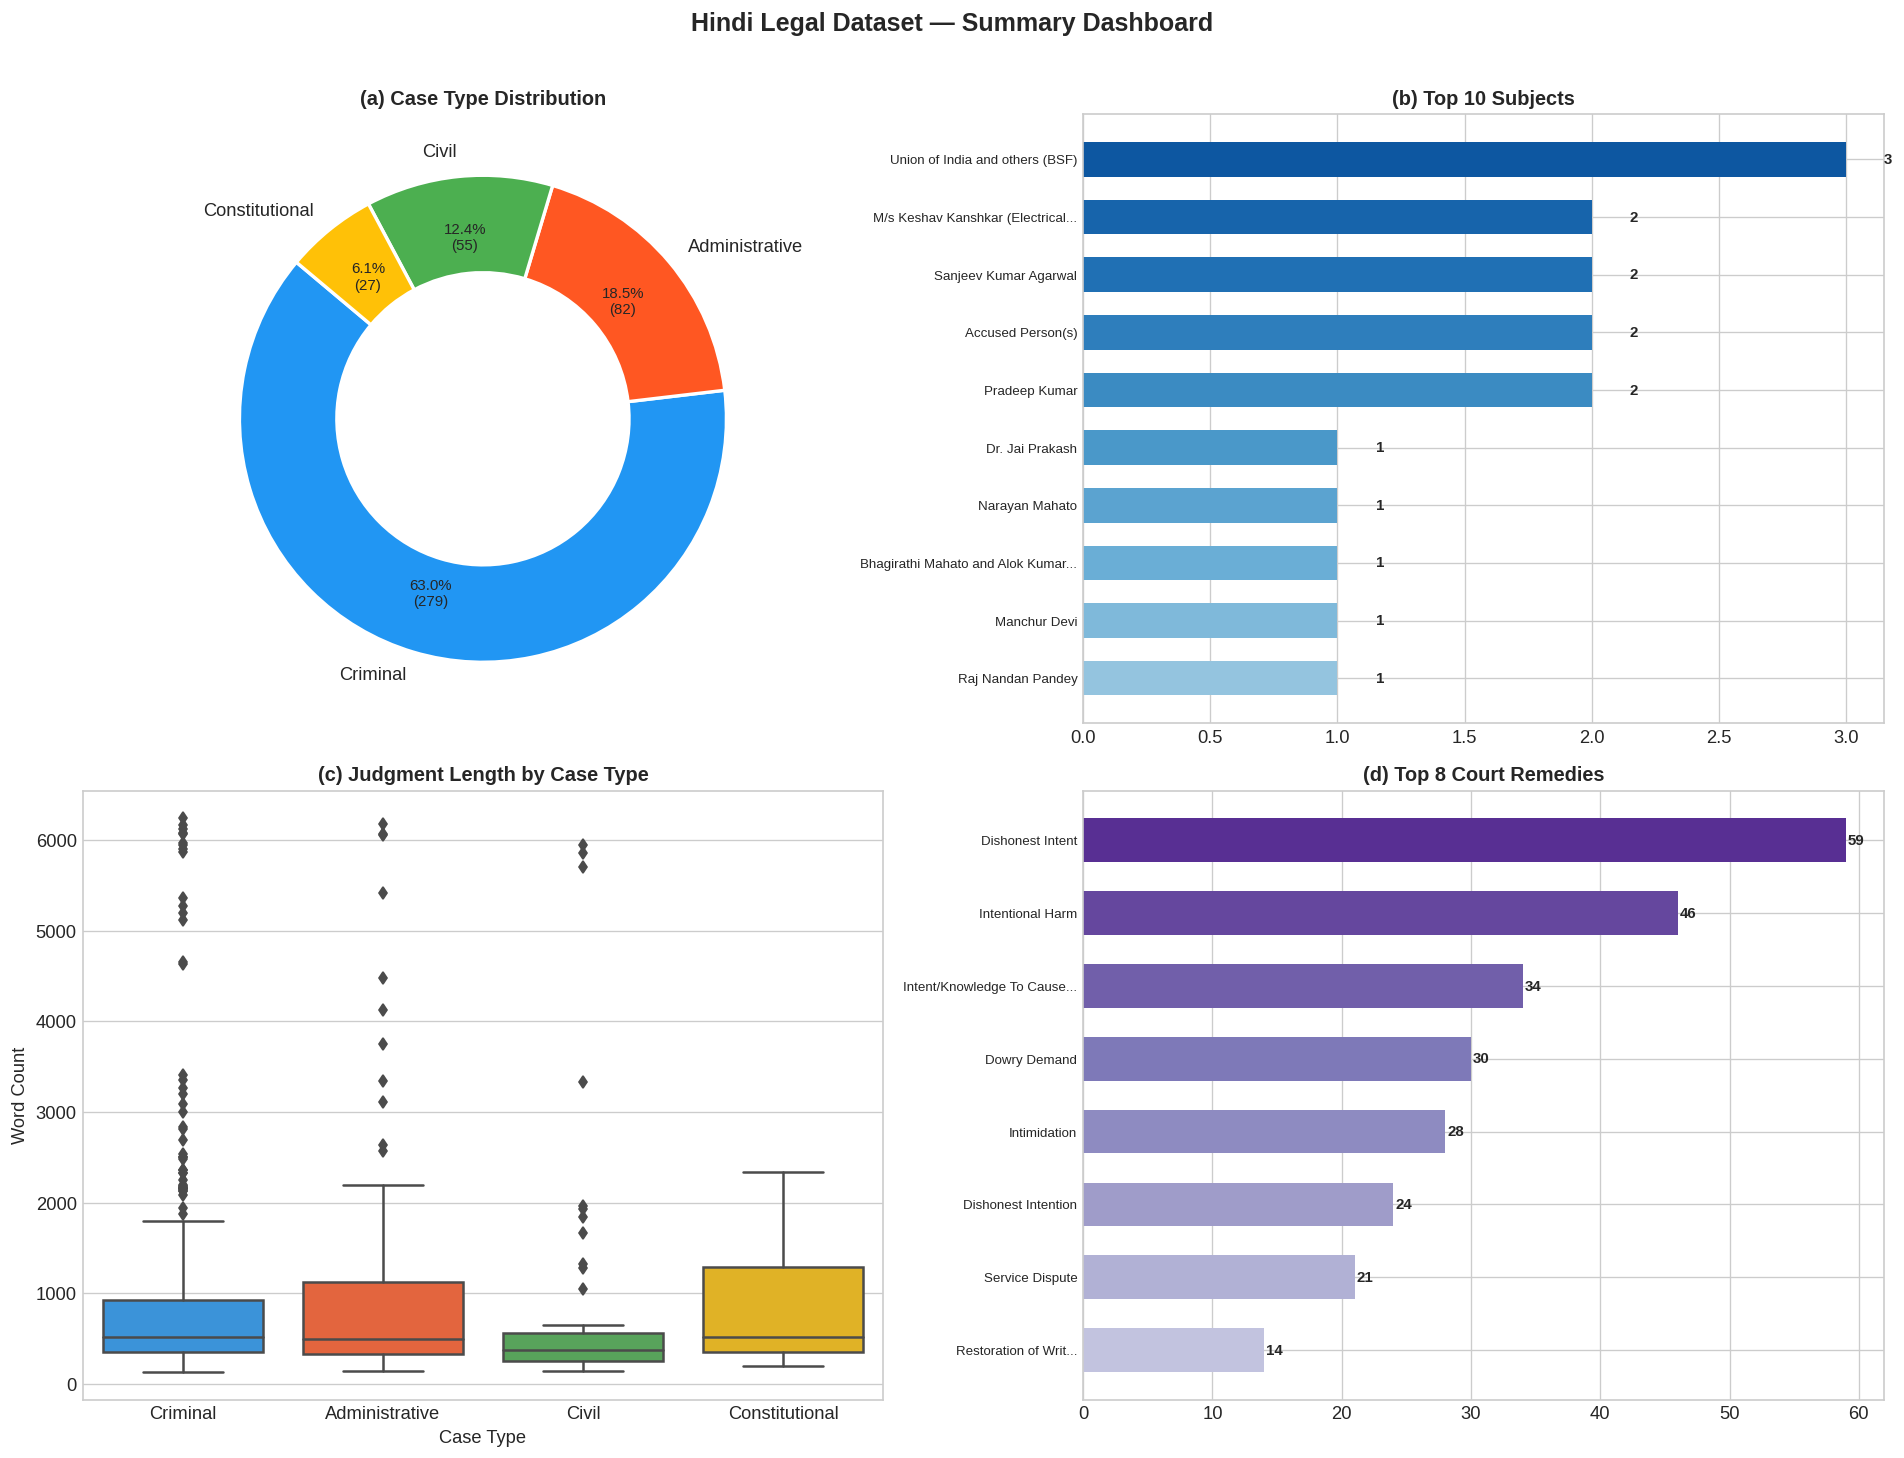

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Case Type Donut
ax = axes[0, 0]
case_counts = df_clean['case_type'].value_counts()
wedges, texts, autotexts = ax.pie(
    case_counts.values, labels=case_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(case_counts.values)/100)})',
    colors=COLORS[:4], startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('(a) Case Type Distribution', fontsize=12, fontweight='bold')

# (b) Top 10 Subjects
ax = axes[0, 1]
top10_sub = df_clean['subject'].value_counts().head(10)
labels_b = [textwrap.shorten(str(s), width=35, placeholder='...') for s in top10_sub.index[::-1]]
bars = ax.barh(range(len(top10_sub)), top10_sub.values[::-1],
               color=plt.cm.Blues(np.linspace(0.4, 0.85, len(top10_sub))), height=0.6)
for bar, val in zip(bars, top10_sub.values[::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, fontweight='bold')
ax.set_yticks(range(len(top10_sub)))
ax.set_yticklabels(labels_b, fontsize=8)
ax.set_title('(b) Top 10 Subjects', fontsize=12, fontweight='bold')

# (c) Word Count by Case Type
ax = axes[1, 0]
sns.boxplot(data=df_clean, x='case_type', y='word_count', order=order,
            palette=COLORS[:4], ax=ax)
ax.set_xlabel('Case Type')
ax.set_ylabel('Word Count')
ax.set_title('(c) Judgment Length by Case Type', fontsize=12, fontweight='bold')

# (d) Top 8 Court Remedies
ax = axes[1, 1]
top8_rem = df_clean['subj_aspect_main'].value_counts().head(8)
labels_d = [textwrap.shorten(str(s), width=30, placeholder='...') for s in top8_rem.index[::-1]]
bars = ax.barh(range(len(top8_rem)), top8_rem.values[::-1],
               color=plt.cm.Purples(np.linspace(0.35, 0.85, len(top8_rem))), height=0.6)
for bar, val in zip(bars, top8_rem.values[::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, fontweight='bold')
ax.set_yticks(range(len(top8_rem)))
ax.set_yticklabels(labels_d, fontsize=8)
ax.set_title('(d) Top 8 Court Remedies', fontsize=12, fontweight='bold')

plt.suptitle('Hindi Legal Dataset — Summary Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('11_summary_dashboard.png', bbox_inches='tight', facecolor='white')
plt.show()


## Key Findings

- **Criminal cases dominate** the dataset (~63%), followed by Administrative (~19%) and Civil (~12%).
- **"Reasoning" column is entirely empty** — might need attention or removal.
- **Judgment length varies significantly** across case types — Constitutional cases tend to be longer.
- **"Arbitrary State Action"** and **"Due Process Violation"** are the most common legal issues raised.
- **"Writ of Mandamus"** is the most frequently sought court remedy.
- **Bihar State** departments appear most frequently as respondents (objects).

---
*All plots saved as PNG files for use in reports/presentations.*
